In [16]:
import pandas as pd
from sentence_transformers import SentenceTransformer

In [17]:
df = pd.read_csv(
    "../data/raw/Student_Feedback.csv",
    encoding="latin-1"
)

print("Original shape:", df.shape)
print(df.columns.tolist())

Original shape: (1086, 2)
['comments', 'sentiments']


In [18]:
df_model = df.drop_duplicates(
    subset=["comments"]
).copy()

df_model = df_model.reset_index(drop=True)

print("After removing raw duplicates:", df_model.shape)

After removing raw duplicates: (1063, 2)


In [19]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully!


In [20]:
comments = df_model["comments"].tolist()

embeddings = model.encode(
    comments,
    show_progress_bar=True
)

print("Embedding shape:", embeddings.shape)

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Embedding shape: (1063, 384)


In [22]:
text1 = "more attention be focused on practical work"
text2 = "the teacher was very kind and helpful"

emb1 = model.encode([text1])
emb2 = model.encode([text2])

similarity = cosine_similarity(emb1, emb2)[0][0]

print("Comment 1:", text1)
print("Comment 2:", text2)
print("Cosine similarity:", similarity)

Comment 1: more attention be focused on practical work
Comment 2: the teacher was very kind and helpful
Cosine similarity: 0.23134454


In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 9)
sbert_silhouette_scores = {}

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(embeddings)
    
    score = silhouette_score(
        embeddings,
        labels
    )
    
    sbert_silhouette_scores[k] = score
    
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.0807
K = 3, Silhouette Score = 0.0348
K = 4, Silhouette Score = 0.0322
K = 5, Silhouette Score = 0.0289
K = 6, Silhouette Score = 0.0347
K = 7, Silhouette Score = 0.0393
K = 8, Silhouette Score = 0.0388


In [24]:
best_k = 2

kmeans_sbert = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

sbert_labels = kmeans_sbert.fit_predict(embeddings)

df_model["sbert_cluster"] = sbert_labels

print(df_model["sbert_cluster"].value_counts().sort_index())

sbert_cluster
0    620
1    443
Name: count, dtype: int64


In [25]:
for cluster in range(best_k):
    print(f"\n{'=' * 60}")
    print(
        f"CLUSTER {cluster} | "
        f"SIZE: {(df_model['sbert_cluster'] == cluster).sum()}"
    )
    print(f"{'=' * 60}")
    
    comments = df_model[
        df_model["sbert_cluster"] == cluster
    ]["comments"].head(15)
    
    for i, comment in enumerate(comments, 1):
        print(f"{i}. {comment}")


CLUSTER 0 | SIZE: 620
1. TEACHERS HELP US IN CAREER BUILDING
2. Having no technical knowledge about their taught subject
3. teacher should give us the practical knowledge other than theortical
4. better teaching methodology
5. best teaching method
6. teaching method is very tough and very diffcult to understand
7. teachers give us all the required information to improve the performance.
8. Your teaching style is engaging
9. teacher was kind
10. even when we asked some irrelevant question teacher gave proper attention to them
11. Professor should be free on his teaching styles
12. teachers turn down the leave
13.  teacher sometimes passes MOCKING remarks
14. Teacher may assess the students at lower level
15. student assessment should be uniform

CLUSTER 1 | SIZE: 443
1. THEY IMPART modern and latest knowledge to us
2. least EXPOSURE to modern trends discussed
3. why did not you play cricket with us
4. You give proper important to it
5. you make learning a truly enjoyable experience.
6.

In [26]:
kmeans_sbert_7 = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

sbert_labels_7 = kmeans_sbert_7.fit_predict(embeddings)

df_model["sbert_cluster_7"] = sbert_labels_7

print(
    df_model["sbert_cluster_7"]
    .value_counts()
    .sort_index()
)

sbert_cluster_7
0    156
1     56
2     96
3    253
4    172
5    186
6    144
Name: count, dtype: int64


In [27]:
for cluster in range(7):
    print(f"\n{'=' * 60}")
    print(
        f"CLUSTER {cluster} | "
        f"SIZE: {(df_model['sbert_cluster_7'] == cluster).sum()}"
    )
    print(f"{'=' * 60}")
    
    comments = df_model[
        df_model["sbert_cluster_7"] == cluster
    ]["comments"].head(10)
    
    for i, comment in enumerate(comments, 1):
        print(f"{i}. {comment}")


CLUSTER 0 | SIZE: 156
1. teacher should give us the practical knowledge other than theortical
2. better teaching methodology
3. best teaching method
4. teaching method is very tough and very diffcult to understand
5. teachers give us all the required information to improve the performance.
6. Your teaching style is engaging
7. teacher was kind
8. FACULTY DID TREMENDOUS JOB OF TEACHING DURING COVID
9. AWESOME PERFORMANCE by the instructor
10. The counseling for the practical life and Character upbringing should also go hand in hand with course.

CLUSTER 1 | SIZE: 56
1. Practical and easy learning
2. you taught us data analysis, that was awesome
3. I have also earned as a freelancer usign jupyter notebook. It is all because of you sir, thank you
4. I will become a data analyst. It is all because of you
5. after you taught us data mining, I have chosen it as a field for my career
6. with your given guidance and with our continuous effort and hardwork we can be data scientist
7. we learnt

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Centroids from our K=7 K-Means model
centroids = kmeans_sbert_7.cluster_centers_

for cluster in range(7):

    # Get indices belonging to this cluster
    cluster_indices = np.where(
        sbert_labels_7 == cluster
    )[0]

    # Get their embeddings
    cluster_embeddings = embeddings[cluster_indices]

    # Similarity of each comment to the cluster centroid
    similarities = cosine_similarity(
        cluster_embeddings,
        centroids[cluster].reshape(1, -1)
    ).flatten()

    # Top 5 most representative comments
    top_indices = similarities.argsort()[-5:][::-1]

    print(f"\n{'=' * 70}")
    print(f"CLUSTER {cluster} | SIZE: {len(cluster_indices)}")
    print(f"{'=' * 70}")

    for rank, idx in enumerate(top_indices, 1):
        original_idx = cluster_indices[idx]
        print(
            f"{rank}. "
            f"{df_model.iloc[original_idx]['comments']}"
        )


CLUSTER 0 | SIZE: 156
1. the way of teaching is good
2. method of teaching is so good
3. your way of teaching is very good
4. sir your method of teaching is so good
5. teaching method is good

CLUSTER 1 | SIZE: 56
1. i learnt about computer hardware and programming
2. we learnt about computers and programming in your lectures
3. we learnt a lot from you such as programming and about modern computers
4. we learnt a lot about comptuers and programming in your lectures sir
5. my programming skills were developed in this course 

CLUSTER 2 | SIZE: 96
1. he teaches in a good manner
2. he takes good lectures
3. he tries to deliver lectures in the best possible way
4. His way of teaching is so good that students dont miss his even a single class and take all lectures
5. he is passionate about the teaching

CLUSTER 3 | SIZE: 253
1. teachers are not good
2. teacher have no comnad over the subject
3. behaviour of teachers should be ideal
4. teachers burden the students
5. teachers favor some st

In [29]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce 384-dimensional SBERT embeddings to 2 dimensions
pca = PCA(n_components=2, random_state=42)

embeddings_2d = pca.fit_transform(embeddings)

print("Original shape:", embeddings.shape)
print("Reduced shape:", embeddings_2d.shape)

Original shape: (1063, 384)
Reduced shape: (1063, 2)


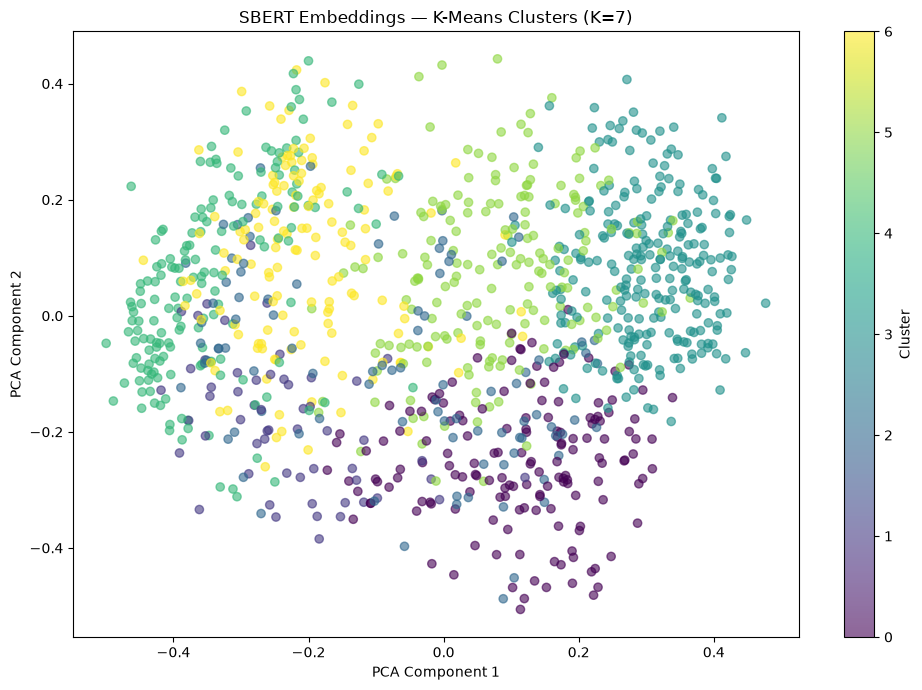

In [38]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=sbert_labels_7,
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SBERT Embeddings — K-Means Clusters (K=7)")
plt.colorbar(scatter, label="Cluster")

plt.tight_layout()
plt.savefig("../results/figures/sbert_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

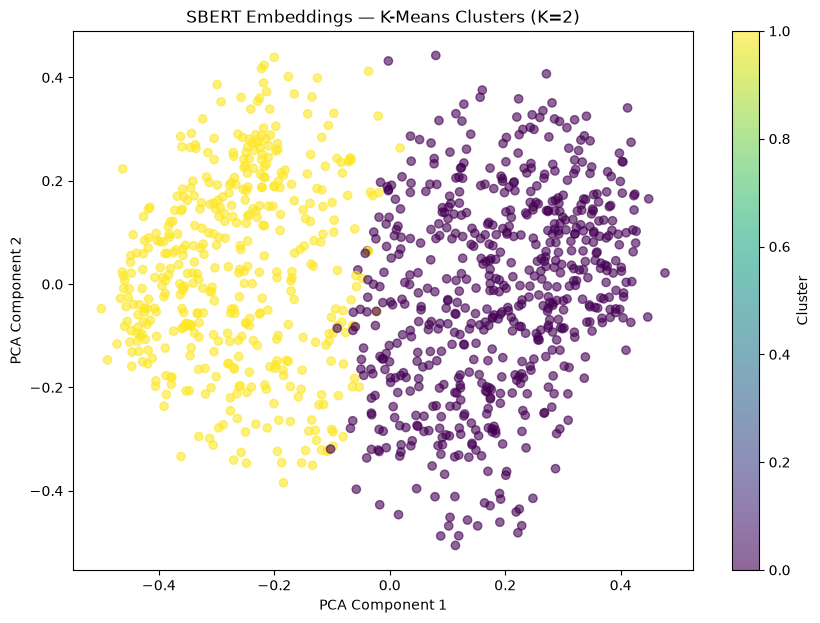

In [31]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=sbert_labels,
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SBERT Embeddings — K-Means Clusters (K=2)")
plt.colorbar(scatter, label="Cluster")

plt.show()

In [32]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

centroids_k2 = kmeans_sbert.cluster_centers_

for cluster in range(2):

    cluster_indices = np.where(
        sbert_labels == cluster
    )[0]

    cluster_embeddings = embeddings[cluster_indices]

    similarities = cosine_similarity(
        cluster_embeddings,
        centroids_k2[cluster].reshape(1, -1)
    ).flatten()

    top_indices = similarities.argsort()[-15:][::-1]

    print(f"\n{'=' * 70}")
    print(f"CLUSTER {cluster} | SIZE: {len(cluster_indices)}")
    print(f"{'=' * 70}")

    for rank, idx in enumerate(top_indices, 1):
        original_idx = cluster_indices[idx]

        print(
            f"{rank}. "
            f"{df_model.iloc[original_idx]['comments']}"
        )


CLUSTER 0 | SIZE: 620
1. Teachers try to understands the entire class.
2. few teachers really encourage students 
3. teacher knows how to handle the class
4. teacher have no comnad over the subject
5. teachers are not good
6. some teachers are perfect
7. teacher behaviour is very nice
8. a teacher should be encouraging
9. teachers pursuade students to learn
10. Some of the teacher are inexperienced.
11. Teachers are punctual and very helpful.
12. student likes those teachers who have indepth knowledge
13. some teachers are partial in their approach
14. teachers appreciate the students
15. teachers understand the problems of students

CLUSTER 1 | SIZE: 443
1. you encourage us to learnt
2. we gained a lot of knowledge in your subjects
3. having solid Knowledge of subject
4. sir you taught we in an excellent manner but we were new entrants to this field of knowledge
5. we learnt a lot from you regarding academics as well as life
6. they encourage us to present our knowledge
7. great apti

In [33]:
cluster_sentiment = pd.crosstab(
    df_model["sbert_cluster"],
    df_model["sentiments"]
)

print(cluster_sentiment)

sentiments       0    1   2
sbert_cluster              
0              271  293  56
1              144  256  43


In [34]:
cluster_sentiment_pct = pd.crosstab(
    df_model["sbert_cluster"],
    df_model["sentiments"],
    normalize="index"
) * 100

print(cluster_sentiment_pct.round(2))

sentiments         0      1     2
sbert_cluster                    
0              43.71  47.26  9.03
1              32.51  57.79  9.71


In [35]:
cluster_sentiment_mean = (
    df_model
    .groupby("sbert_cluster")["sentiments"]
    .mean()
)

print(cluster_sentiment_mean)

sbert_cluster
0    0.653226
1    0.772009
Name: sentiments, dtype: float64


In [36]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Similarity of every comment to both cluster centroids
similarities = cosine_similarity(
    embeddings,
    kmeans_sbert.cluster_centers_
)

# Difference between similarity to cluster 0 and cluster 1
similarity_difference = np.abs(
    similarities[:, 0] - similarities[:, 1]
)

# Small difference = ambiguous/boundary comment
boundary_indices = np.argsort(similarity_difference)[:20]

print("=" * 80)
print("MOST AMBIGUOUS COMMENTS")
print("=" * 80)

for rank, idx in enumerate(boundary_indices, 1):

    print(f"\n{rank}. {df_model.iloc[idx]['comments']}")
    print(f"   Assigned cluster: {sbert_labels[idx]}")
    print(f"   Similarity to Cluster 0: {similarities[idx, 0]:.4f}")
    print(f"   Similarity to Cluster 1: {similarities[idx, 1]:.4f}")
    print(f"   Difference: {similarity_difference[idx]:.4f}")

MOST AMBIGUOUS COMMENTS

1. foucs on course contents instead of lab practical work
   Assigned cluster: 1
   Similarity to Cluster 0: 0.3684
   Similarity to Cluster 1: 0.3688
   Difference: 0.0005

2. everything is good about the faculty members
   Assigned cluster: 0
   Similarity to Cluster 0: 0.5145
   Similarity to Cluster 1: 0.5136
   Difference: 0.0009

3. during learning process, you put burden on us which makes our life difficult
   Assigned cluster: 0
   Similarity to Cluster 0: 0.5465
   Similarity to Cluster 1: 0.5477
   Difference: 0.0012

4. course is not completed in timely
   Assigned cluster: 1
   Similarity to Cluster 0: 0.3575
   Similarity to Cluster 1: 0.3591
   Difference: 0.0016

5. she takes all the lectures on time
   Assigned cluster: 1
   Similarity to Cluster 0: 0.4093
   Similarity to Cluster 1: 0.4072
   Difference: 0.0022

6. Lab work is properly covered in the labs by the faculty and evaluations help to learn more. 
   Assigned cluster: 1
   Similarity t

In [37]:
thresholds = [0.01, 0.02, 0.05]

for threshold in thresholds:
    count = np.sum(
        similarity_difference < threshold
    )
    
    percentage = (
        count / len(similarity_difference)
    ) * 100
    
    print(
        f"Difference < {threshold:.2f}: "
        f"{count} comments "
        f"({percentage:.2f}%)"
    )

Difference < 0.01: 16 comments (1.51%)
Difference < 0.02: 32 comments (3.01%)
Difference < 0.05: 110 comments (10.35%)
